 '날짜별', '지점별'로 수많은 대출 건수가 나열. 
 '월별'이나 '지역별'로 묶으면, 한 그룹 안에 여러 개의 숫자가 모임.
 "이 모인 숫자들을 어떻게 처리할지?"
  aggfunc(Aggregation Function, 집계 함수)
aggfunc='sum': "다 더해서 총액을." (예: 이번 달 총 대출액)
aggfunc='mean': "평균을 내서 평균치를." (예: 이번 달 평균 금리)
aggfunc='count': "데이터가 몇 건인지" (예: 이번 달 대출 승인 건수)

# 지점별로 대출실행액의 '합계'를 구하는 피벗 테이블
pivot_df = df.pivot_table(index='지점명', values='대출실행액', aggfunc='sum')

🧐 만약 합계와 평균을 동시에 보고 싶다면?
aggfunc=['sum', 'mean']

In [ ]:
#🟢concat 위에서 아래 이어붙이기 unstack
import pandas as pd
import numpy as np

# 강남점 데이터
df_gangnam = pd.DataFrame({
    '판매ID': ['A1', 'A2', 'A3'],
    '상품': ['커피', '주스', '커피'],
    '매출': [5000, 6000, 5200],
    '지점': '강남'
})

# 홍대점 데이터
df_hongdae = pd.DataFrame({
    '판매ID': ['B1', 'B2', 'B3'],
    '상품': ['커피', '커피', '주스'],
    '매출': [5100, 4900, 6200],
    '지점': '홍대'
})

# 1️⃣concat 데이터 합치기: 흩어져 있는 두 지점의 데이터를 위아래로 붙임
df_total = pd.concat([df_gangnam, df_hongdae], ignore_index=True)
df_total

# 2️⃣groupby + mean 그룹화 및 평균 계산 
# "지점별로, 상품별 매출 평균이 얼마인가?"
# groupby에 리스트를 넣으면 여러 기준으로 묶을 수 있습니다.
# group_mean = df_total.groupby(['지점', '상품'])['매출'].mean()
# group_mean
# 3️⃣unstack p368 (통계표) 세로로 길게 나온 결과를 가로로 펼침.
# pivot_table = group_mean.unstack()
# print("--- [최종 분석 표] ---")
# print(pivot_table)

,판매ID,상품,매출,지점
0,A1,커피,5000,강남
1,A2,주스,6000,강남
2,A3,커피,5200,강남
3,B1,커피,5100,홍대
4,B2,커피,4900,홍대
5,B3,주스,6200,홍대


In [63]:
#🟢Merge 합치기 p347
# "회원번호" 같은 공통 🟢열을 기준으로 두 표를 옆으로 조립(Join)할 때 씀.
import pandas as pd

# 데이터 생성 (실습용)
df_sales = pd.DataFrame({'사번': [101, 102, 103], '매출': [500, 700, 300]})
df_info = pd.DataFrame({'사번': [101, 102, 103], '이름': ['홍길동', '김철수', '이영희'], '부서': ['영업1팀', '영업2팀', '기획팀']})

# [VLOOKUP 한 줄 해결] 🍋🔴사번을 기준으로 🍋두 표를 합침
result = pd.merge(df_sales, df_info, on='사번')

print(result)

    사번   매출   이름    부서
0  101  500  홍길동  영업1팀
1  102  700  김철수  영업2팀
2  103  300  이영희   기획팀


In [71]:
#🟢Join으로 두 개의 표(DataFrame) 비어있는 (결측치) 셀 포함 합치기
#🟢인덱스(번호나 이름표)를 기준으로
# 데이터베이스의 SQL Join과 유사
import pandas as pd

# 1. 준비: 두 개의 표(DataFrame) 만들기
# 왼쪽 표: 사원 이름 (인덱스: 사번)
df_left = pd.DataFrame({'이름': ['철수', 
                               '영희', '민수']}, index=['A01', 'A02', 'A03'])

# 오른쪽 표: 급여 정보 (인덱스: 사번)
df_right = pd.DataFrame({'급여': [300, 400, 500]}, index=['A01', 'A02', 'A04'])

print("--- [합치기 전] 왼쪽 표 (사원명단) ---")
print(df_left)
print("\n--- [합치기 전] 오른쪽 표 (급여현황) ---")
print(df_right)
print("-" * 40)

# 2. Join 실행 (기본값은 Left Join입니다)
# 1️⃣왼쪽(df_left)을 기준으로 오른쪽(df_right)의 '급여' 컬럼을 가져와 붙임.
joined_df = df_left.join(df_right)
# joined_df = df_left.join(df_right, how='outer') # 2️⃣A04 데이터도 사라지지 않고 나타남

print("\n--- [합친 후] 결과 표 (Joined) ---")
print(joined_df)

# 3. 결과 해석 (결측치 발생 이유)
print("\n💡 해석:")
print("- A01, A02는 양쪽에 다 있어서 이름과 급여가 잘 합쳐졌습니다.")
print("- A03(민수)은 급여 표에 없어서 급여가 NaN(결측치)으로 나옵니다.")
print("- A04는 급여 표에만 있고 사원 명단엔 없어서 최종 결과에서 제외되었습니다.")


--- [합치기 전] 왼쪽 표 (사원명단) ---
     이름
A01  철수
A02  영희
A03  민수

--- [합치기 전] 오른쪽 표 (급여현황) ---
      급여
A01  300
A02  400
A04  500
----------------------------------------

--- [합친 후] 결과 표 (Joined) ---
     이름     급여
A01  철수  300.0
A02  영희  400.0
A03  민수    NaN

💡 해석:
- A01, A02는 양쪽에 다 있어서 이름과 급여가 잘 합쳐졌습니다.
- A03(민수)은 급여 표에 없어서 급여가 NaN(결측치)으로 나옵니다.
- A04는 급여 표에만 있고 사원 명단엔 없어서 최종 결과에서 제외되었습니다.


In [1]:
#🟢pivot_table 🟢groupby 그룹화와 평균
import pandas as pd

data = {
    '부서': ['인사팀', 'IT팀', '인사팀', 'IT팀', '기획팀'],
    '항목': ['비품', '서버', '회식', '소프트웨어', '도서'],
    '비용': [150, 500, 200, 300, 50]
}
df = pd.DataFrame(data)

# groupby 그룹화 [피벗 테이블 한 줄 해결] 부서별 비용 🍋합계 계산
# aggfunc='sum' 그룹화된 데이터의 합계를 계산하는 인자
pivot = df.pivot_table(index='부서', values='비용', aggfunc='sum') 
pivot2 = df.groupby('부서')['비용'].mean() # 🔴부서별 비용 🍋평균 한 줄 컷! 
print("<부서별 비용> \n", pivot) #2️⃣mean 대신 count로 해보기
print("\n<부서별 비용 평균> \n",pivot2)

<부서별 비용> 
       비용
부서      
IT팀  800
기획팀   50
인사팀  350

<부서별 비용 평균> 
 부서
IT팀    400.0
기획팀     50.0
인사팀    175.0
Name: 비용, dtype: float64


In [ ]:
#🟢p298
ages = [20, 22, 25, 27, 21, 23, 37, 31, 61, 45, 41, 32]
bins = [18, 25, 35, 60, 100]
age_categories = pd.cut(ages, bins)
age_categories
# print(len(age_categories))
age_categories.codes
age_categories.categories
age_categories.categories[0]

group_names = ["젊은", "청년", "중년", "노인"]
pd.cut(ages, bins, labels=group_names)

# 🟢그래프를 그리기 직전에 꼭 df.info()나 df.isnull().sum()
#  **결측치(빈 칸)**가 없는지 확인하는 습관(아래 셀)

['젊은', '젊은', '젊은', '청년', '젊은', ..., '청년', '노인', '중년', '중년', '청년']
Length: 12
Categories (4, str): ['젊은' < '청년' < '중년' < '노인']

isnull 비어있는지 확인 🔴
user_id    0
birth      0
gender     0
applied    0
dtype: int64
   user_id      birth gender  applied  age age_group
0     1001 2003-03-31      남        0   23    20대 이하
1     1002 1962-05-10      남        0   63    50대 이상
2     1003 1974-10-04      남        0   51    50대 이상
3     1004 1992-10-03      남        1   33       30대
4     1005 1990-11-23      여        1   35       30대
피봇🟠
applied                   0          1
age_group gender                      
20대 이하    남       71.428571  28.571429
          여       20.833333  79.166667
30대       남       61.904762  38.095238
          여       37.500000  62.500000
40대       남       66.666667  33.333333
          여       54.166667  45.833333
50대 이상    남       80.000000  20.000000
          여       54.054054  45.945946
--- 연령대별/성별 신청 🟢비율 (%) ---
      연령대 성별       신청비율
0  20대 이하  남  28.571429
1  20대 이하  여  79.166667
2     30대  남  38.095238
3     30대  여  62.500000
4     40대  남  33.333333
5     40대  여  45.833333
6  50대 이상 

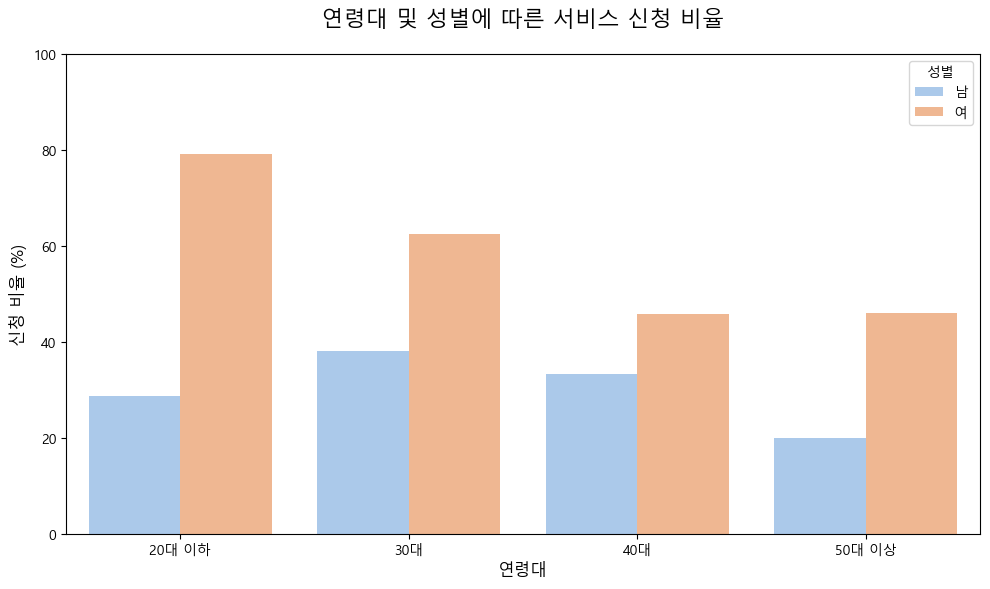

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date

# 한글 폰트 설정 (필수!)
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows용
plt.rcParams['axes.unicode_minus'] = False # 마이너스 깨짐 방지

# 1. 데이터 로드 (2️⃣ 미리 확인 습관)
df = pd.read_csv('reception_data.csv')
# print("info 정보 출력") #2️⃣
# df.info()
print("isnull 비어있는지 확인 🔴p285")
print(df.isnull().sum())
# 날짜 데이터는 읽어올 때 문자열이므로 1️⃣datetime으로 변환 필수!
df['birth'] = pd.to_datetime(df['birth']) 

# 2. [전처리 핵심] 생년월일 -> 만나이 계산 함수
today = date.today()
def calculate_age(born):
    return today.year - born.year - ((today.month, today.day) < (born.month, born.day))
# 튜플끼리 < 비교를 하면 True 1 False 0 //생일이 안 지났으면 1을 빼고, 지났으면 0빼는
df['age'] = df['birth'].apply(calculate_age)

# 3. [전처리 핵심] 나이 -> 연령대 그룹화 (pd.cut)
bins = [0, 29, 39, 49, 100]
group_names = ['20대 이하', '30대', '40대', '50대 이상']
df['age_group'] = pd.cut(df['age'], bins, labels=group_names)
print(df.head()) #🟢3️⃣ 열 추가 확인! (기존 열에 덮어쓰면 곤란)

# 4. [분석 핵심] 연령대별/성별 신청 비율 계산 (pd.crosstab)
# normalize='index'를 하면 각 행(연령대)별로 비율을 계산해 줍니다.
pivot_df = pd.crosstab(index=[df['age_group'], df['gender']], 
                       columns=df['applied'], 
                       normalize='index') * 100
print("피봇🟠")
print(pivot_df) #요약된 통계표에서
# 우리가 필요한 건 '신청[1]'열의 비율이므로 그것만 추출
apply_rate_df = pivot_df[1].reset_index() #다림질
apply_rate_df.columns = ['연령대', '성별', '신청비율'] # 컬럼명 정리

print("--- 연령대별/성별 신청 🟢비율 (%) ---")
print(apply_rate_df)

# 5. [시각화] 다차원 막대그래프 (Seaborn 활용)
plt.figure(figsize=(10, 6))
# x축: 연령대, y축: 신청비율, 색상(hue): 성별
sns.barplot(data=apply_rate_df, x='연령대', y='신청비율', hue='성별', palette='pastel')

plt.title('연령대 및 성별에 따른 서비스 신청 비율', fontsize=16, pad=20)
plt.ylabel('신청 비율 (%)', fontsize=12)
plt.xlabel('연령대', fontsize=12)
plt.ylim(0, 100) # 비율이므로 y축은 0~100 고정
plt.legend(title='성별')

# 비율 숫자 표시 (디테일 팁)
# for p in plt.gca().patches:
#     width = p.get_width()
#     height = p.get_height()
#     x, y = p.get_xy() 
#     if height > 0: # 0보다 클 때만 표시
#         plt.annotate(f'{height:.1f}%', (x + width/2, y + height*1.02), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [75]:
# 파일 생성 코드 (참고용- 예시 파일 만들기 용)
import pandas as pd
import numpy as np
from datetime import date, timedelta

np.random.seed(42)
num_users = 200
start_date = date(1960, 1, 1)
end_date = date(2005, 12, 31)
days_between = (end_date - start_date).days
birthdays = [start_date + timedelta(days=np.random.randint(0, days_between)) for _ in range(num_users)]
genders = np.random.choice(['남', '여'], num_users)
applied = []
for i in range(num_users):
    age_approx = 2026 - birthdays[i].year
    prob = 0.6 if age_approx < 35 else 0.3
    if genders[i] == '여': prob += 0.15
    applied.append(np.random.binomial(1, min(prob, 1.0)))

df = pd.DataFrame({'user_id': range(1001, 1001 + num_users), 'birth': birthdays, 'gender': genders, 'applied': applied})
df.to_csv('reception_data.csv', index=False, encoding='utf-8-sig')

'여러 개의 데이터를 하나로 합칠 때 사용하는 통계 함수'를 지정하는 매개변수입니다. Aggregation Function의 약어입니다.판다스(Pandas)의 pivot_table이나 groupby 등에서 주로 사용

mean': 평균 (기본값)'sum': 합계'count': 데이터 개수'max' / 'min': 최댓값 / 최솟값'std': 표준편차

3. 여러 함수를 한꺼번에 적용하기리스트 형태나 딕셔너리 형태로 전달하여 복합적인 통계를 낼 수도
aggfunc=['mean', 'sum']: 평균과 합계를 동시에 계산aggfunc={'매출': 'sum', '나이': 'mean'}: 열마다 서로 다른 함수 적용

🟢데이터 정제 요약
1. 결측치(NaN) 처리하기
비어있는지 확인: df.isnull().sum()
삭제: df.dropna()
평균값으로 채우기: df['컬럼'].fillna(df['컬럼'].mean(), inplace=True)
직전/직후 값으로 채우기: df.fillna(method='ffill') (시계열 데이터)

2. 중복 및 오타 수정
똑같은 데이터나 잘못 들어간 글자 빼내기
중복 제거: df.drop_duplicates()
글자 치환 (예: 'Seoul' -> '서울'): df['city'].replace('Seoul', '서울')
공백 제거: df['name'].str.strip()

3. 데이터 타입 변경
숫자인데 문자열로 되어 있어 계산이 안 될 때 
숫자로 변환: df['price'] = pd.to_numeric(df['price'], errors='coerce') (에러는 NaN 처리)
날짜로 변환: pd.to_datetime(df['date'])

4. 필터링과 정렬
조건 필터링: df[df['age'] >= 20]
여러 조건: df[(df['age'] >= 20) & (df['gender'] == 'F')]
내림차순 정렬: df.sort_values('count', ascending=False)

5. 그룹화(Groupby)
지역별 평균: df.groupby('region')['salary'].mean()
개수 세기: df['region'].value_counts()